# Exploratory Data Analysis — MovieLens Small Dataset

**Recommender Systems — Individual Assignment · ESADE 2025/26**

This notebook analyses the MovieLens Small dataset (100,836 ratings, 9,742 movies, 610 users) before building any recommender.  
The goal is to understand the data's structure, identify challenges (sparsity, long tail, rating bias), and motivate the algorithm choices made in the project.

---
**Sections**
1. Setup & Data Loading
2. Dataset Overview
3. Rating Distribution
4. User Activity Analysis
5. Item Popularity & the Long Tail
6. Genre Analysis
7. Temporal Analysis
8. Matrix Sparsity
9. Key Findings & Implications

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)

DATA_DIR = Path('ml-latest-small')

ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')
tags    = pd.read_csv(DATA_DIR / 'tags.csv')
links   = pd.read_csv(DATA_DIR / 'links.csv')

print('ratings:', ratings.shape)
print('movies: ', movies.shape)
print('tags:   ', tags.shape)
ratings.head(3)

ratings: (100836, 4)
movies:  (9742, 3)
tags:    (3683, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


---
## 1. Dataset Overview

Basic statistics to characterise the dataset before any modelling.

In [2]:
n_users   = ratings['userId'].nunique()
n_items   = ratings['movieId'].nunique()
n_ratings = len(ratings)
n_tags    = len(tags)
sparsity  = 1 - n_ratings / (n_users * n_items)
avg_r     = ratings['rating'].mean()
med_r     = ratings['rating'].median()

summary = pd.DataFrame({
    'Metric': [
        'Users', 'Movies (rated)', 'Movies (catalogue)',
        'Ratings', 'Tags', 'Sparsity',
        'Mean rating', 'Median rating',
        'Avg ratings / user', 'Avg ratings / movie',
    ],
    'Value': [
        f'{n_users:,}',
        f'{n_items:,}',
        f"{movies.shape[0]:,}",
        f'{n_ratings:,}',
        f'{n_tags:,}',
        f'{sparsity:.2%}',
        f'{avg_r:.3f}',
        f'{med_r:.1f}',
        f"{ratings.groupby('userId').size().mean():.1f}",
        f"{ratings.groupby('movieId').size().mean():.1f}",
    ]
})
summary.set_index('Metric')

,Value
Metric,
Users,610
Movies (rated),"9,724"
Movies (catalogue),"9,742"
Ratings,"100,836"
Tags,"3,683"
Sparsity,98.30%
Mean rating,3.502
Median rating,3.5
Avg ratings / user,165.3


---
## 2. Rating Distribution

MovieLens uses a 0.5–5 star scale in 0.5 increments.

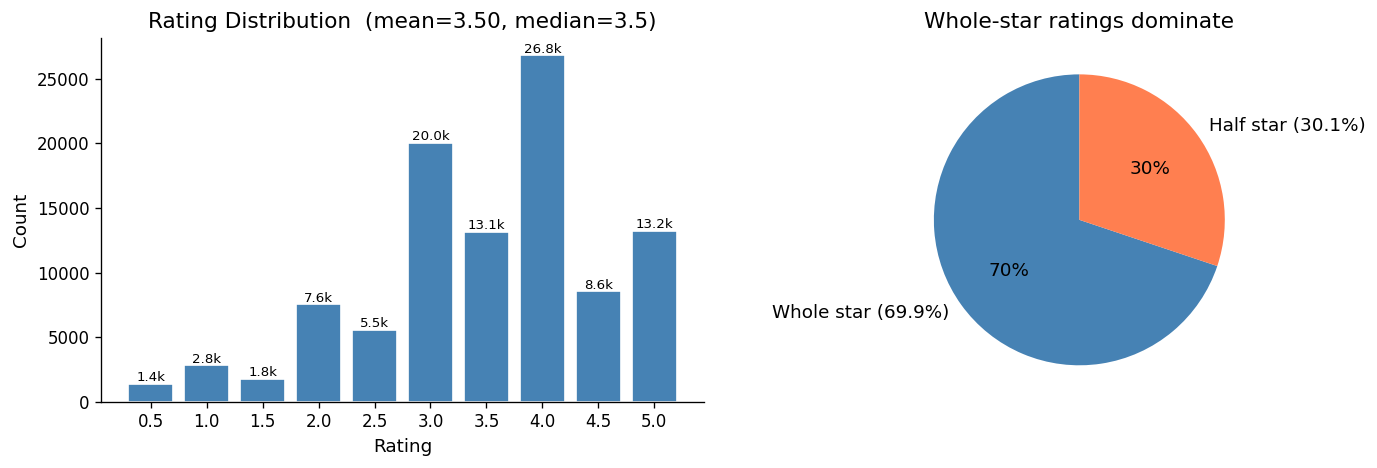


Observation: ratings skew positive (selection bias — users rate movies they chose to watch).
This means implicit feedback models might be worth exploring.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full distribution
counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, width=0.4, color='steelblue', edgecolor='white')
for x, y in zip(counts.index, counts.values):
    axes[0].text(x, y + 200, f'{y/1000:.1f}k', ha='center', fontsize=8)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Rating Distribution  (mean={avg_r:.2f}, median={med_r:.1f})')
axes[0].set_xticks(counts.index)

# Right: half-star vs whole-star
ratings['is_half'] = ratings['rating'] % 1 == 0.5
half_pct = ratings['is_half'].mean() * 100
axes[1].pie([100 - half_pct, half_pct],
            labels=[f'Whole star ({100-half_pct:.1f}%)', f'Half star ({half_pct:.1f}%)'],
            colors=['steelblue', 'coral'], startangle=90,
            autopct='%1.0f%%', textprops={'fontsize': 11})
axes[1].set_title('Whole-star ratings dominate')

plt.tight_layout()
plt.savefig('fig_rating_distribution.png', bbox_inches='tight')
plt.show()

print('\nObservation: ratings skew positive (selection bias — users rate movies they chose to watch).')
print('This means implicit feedback models might be worth exploring.')

---
## 3. User Activity Analysis

How many movies does each user rate? Uneven user activity affects collaborative filtering — users with few ratings are hard to serve (cold-start problem).

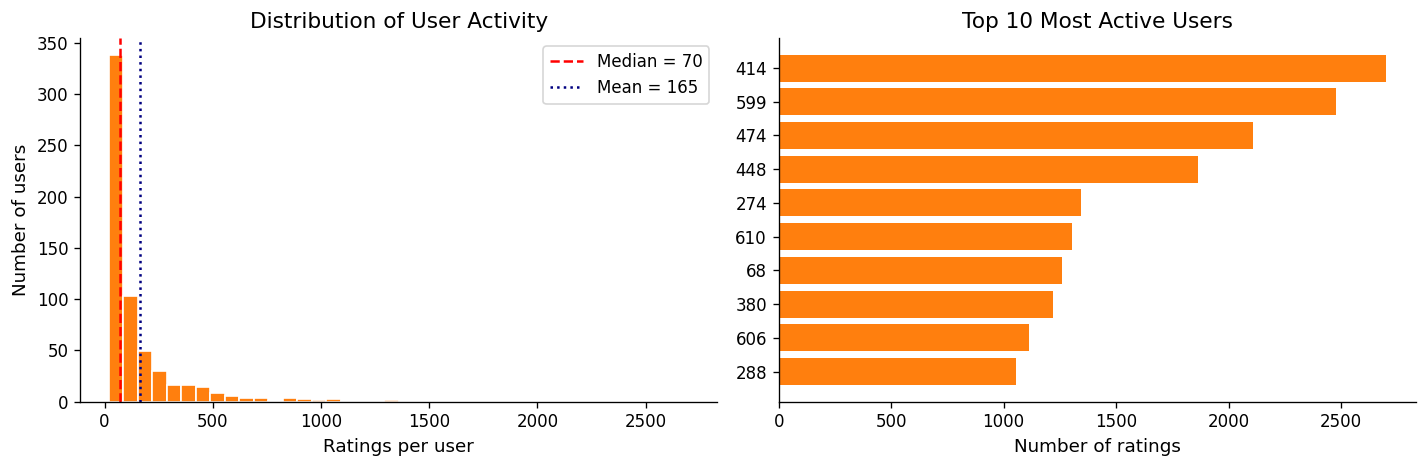

User activity percentiles:
  10th percentile: 24 ratings
  25th percentile: 35 ratings
  50th percentile: 70 ratings
  75th percentile: 168 ratings
  90th percentile: 400 ratings
  99th percentile: 1256 ratings

Users with < 20 ratings (cold-start risk): 0 (0.0%)


In [4]:
user_counts = ratings.groupby('userId').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(user_counts, bins=40, color='#ff7f0e', edgecolor='white')
axes[0].axvline(user_counts.median(), color='red', linestyle='--',
                label=f'Median = {user_counts.median():.0f}')
axes[0].axvline(user_counts.mean(), color='navy', linestyle=':',
                label=f'Mean = {user_counts.mean():.0f}')
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Distribution of User Activity')
axes[0].legend()

# Top 10 most active
top10_users = user_counts.head(10)
axes[1].barh(top10_users.index.astype(str)[::-1], top10_users.values[::-1],
             color='#ff7f0e')
axes[1].set_xlabel('Number of ratings')
axes[1].set_title('Top 10 Most Active Users')

plt.tight_layout()
plt.savefig('fig_user_activity.png', bbox_inches='tight')
plt.show()

# Percentile breakdown
print('User activity percentiles:')
for p in [10, 25, 50, 75, 90, 99]:
    print(f'  {p}th percentile: {np.percentile(user_counts, p):.0f} ratings')

cold_users = (user_counts < 20).sum()
print(f'\nUsers with < 20 ratings (cold-start risk): {cold_users} ({cold_users/n_users:.1%})')

---
## 4. Item Popularity & the Long Tail

A key property of movie catalogues is the **long-tail distribution**: a small number of popular movies receive most ratings while the vast majority have very few. This creates a bias in popularity-based and CF models.

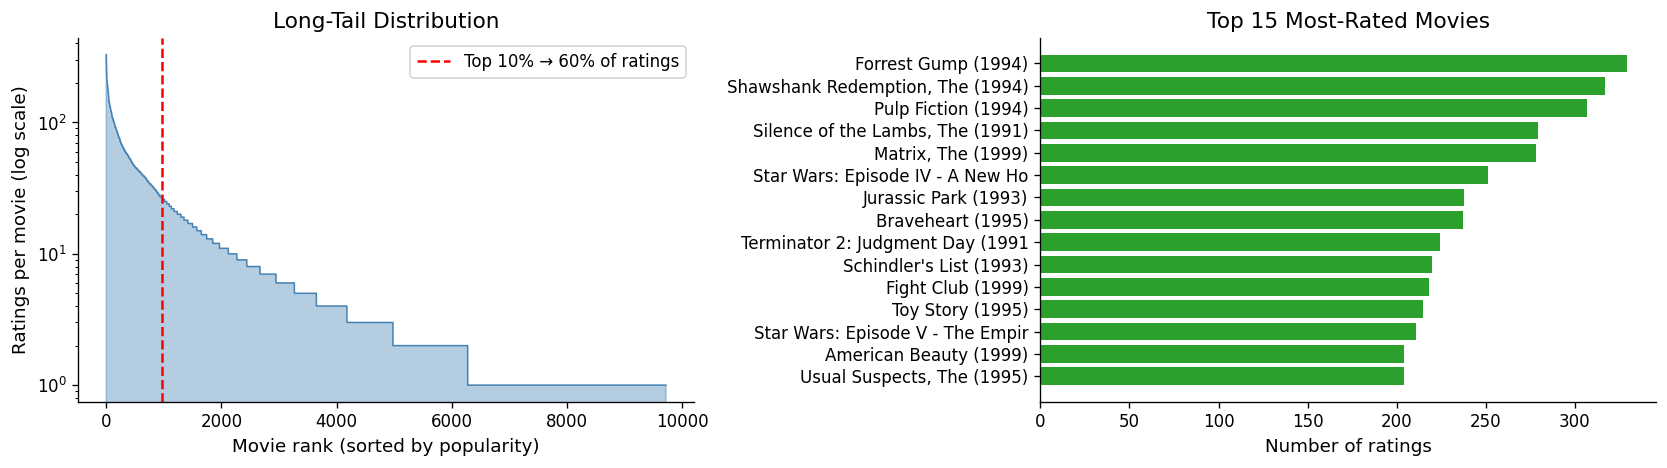

Top 10% of movies (972) account for 60.0% of all ratings.
Movies in catalogue never rated in this dataset: 18
Movies with only 1 rating: 3446


In [5]:
item_counts = ratings.groupby('movieId').size().sort_values(ascending=False).reset_index()
item_counts.columns = ['movieId', 'count']

top10_threshold = int(len(item_counts) * 0.1)
top10_share = item_counts['count'].iloc[:top10_threshold].sum() / item_counts['count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Long-tail curve
axes[0].fill_between(range(len(item_counts)), item_counts['count'].values, alpha=0.4, color='steelblue')
axes[0].plot(range(len(item_counts)), item_counts['count'].values, color='steelblue', lw=0.8)
axes[0].axvline(top10_threshold, color='red', linestyle='--',
                label=f'Top 10% → {top10_share:.0%} of ratings')
axes[0].set_yscale('log')
axes[0].set_xlabel('Movie rank (sorted by popularity)')
axes[0].set_ylabel('Ratings per movie (log scale)')
axes[0].set_title('Long-Tail Distribution')
axes[0].legend()

# Top 15 most-rated movies
top15 = item_counts.head(15).merge(movies[['movieId', 'title']], on='movieId')
top15['short'] = top15['title'].str.slice(0, 32)
axes[1].barh(top15['short'][::-1], top15['count'][::-1], color='#2ca02c')
axes[1].set_xlabel('Number of ratings')
axes[1].set_title('Top 15 Most-Rated Movies')

plt.tight_layout()
plt.savefig('fig_item_popularity.png', bbox_inches='tight')
plt.show()

print(f'Top 10% of movies ({top10_threshold}) account for {top10_share:.1%} of all ratings.')
never_rated = movies.shape[0] - n_items
print(f'Movies in catalogue never rated in this dataset: {never_rated}')
print(f'Movies with only 1 rating: {(item_counts["count"] == 1).sum()}')

---
## 5. Genre Analysis

Genres are the primary content signal used in the content-based recommender. Understanding their distribution tells us which areas are well-covered (Drama, Comedy) and which are sparse (IMAX, Film-Noir).

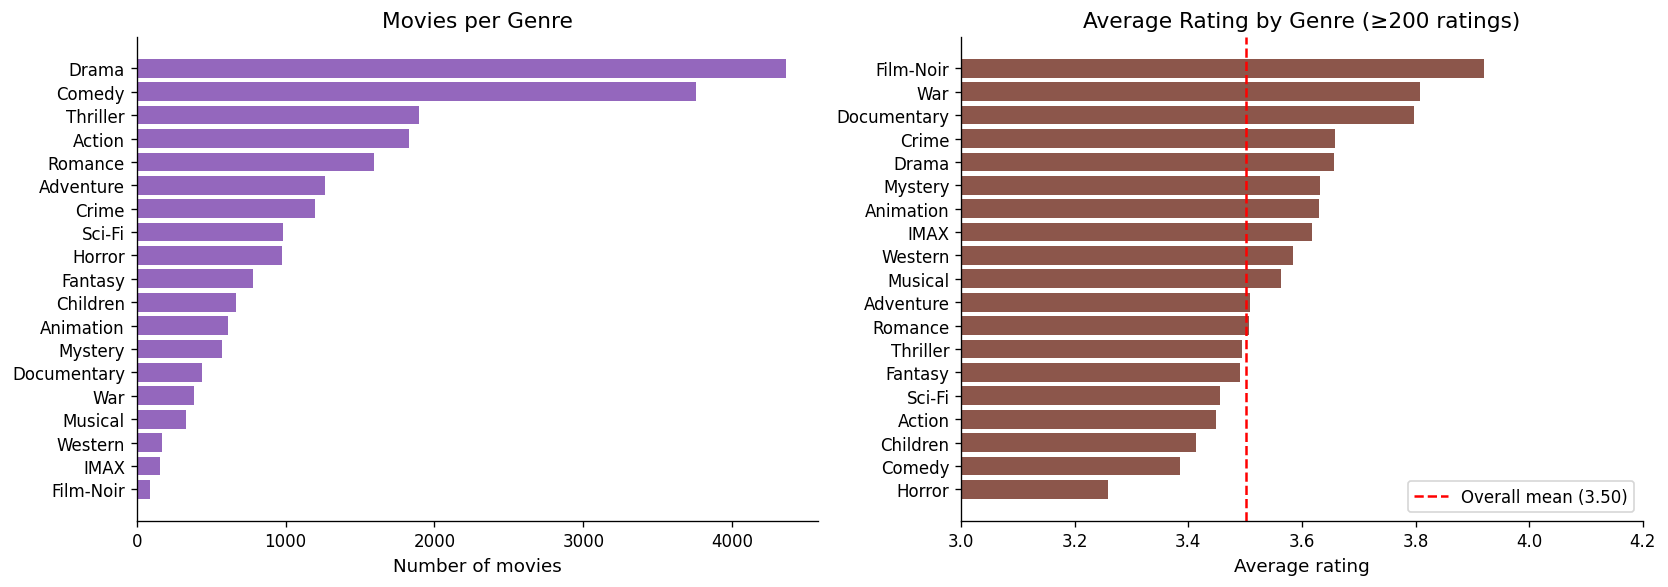

Highest-rated genres (avg):
genre
Film-Noir      3.920115
War            3.808294
Documentary    3.797785
Crime          3.658294
Drama          3.656184

Lowest-rated genres (avg):
genre
Sci-Fi      3.455721
Action      3.447984
Children    3.412956
Comedy      3.384721
Horror      3.258195


In [6]:
# Genre frequency
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres[all_genres != '(no genres listed)'].value_counts()

# Average rating per genre (via ratings join)
movies_expanded = movies.assign(genre=movies['genres'].str.split('|')).explode('genre')
movies_expanded = movies_expanded[movies_expanded['genre'] != '(no genres listed)']
genre_ratings = (ratings
    .merge(movies_expanded[['movieId', 'genre']], on='movieId')
    .groupby('genre')['rating'].agg(['mean', 'count'])
    .query('count >= 200')
    .sort_values('mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre frequency
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='#9467bd')
axes[0].set_xlabel('Number of movies')
axes[0].set_title('Movies per Genre')

# Average rating per genre
axes[1].barh(genre_ratings.index[::-1], genre_ratings['mean'][::-1], color='#8c564b')
axes[1].axvline(avg_r, color='red', linestyle='--', label=f'Overall mean ({avg_r:.2f})')
axes[1].set_xlabel('Average rating')
axes[1].set_title('Average Rating by Genre (≥200 ratings)')
axes[1].set_xlim(3.0, 4.2)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_genre_analysis.png', bbox_inches='tight')
plt.show()

print('Highest-rated genres (avg):')
print(genre_ratings['mean'].head(5).to_string())
print('\nLowest-rated genres (avg):')
print(genre_ratings['mean'].tail(5).to_string())

---
## 6. Temporal Analysis

Understanding when ratings were given can reveal trends (do users rate more during certain periods?) and inform temporal train/test split strategies.

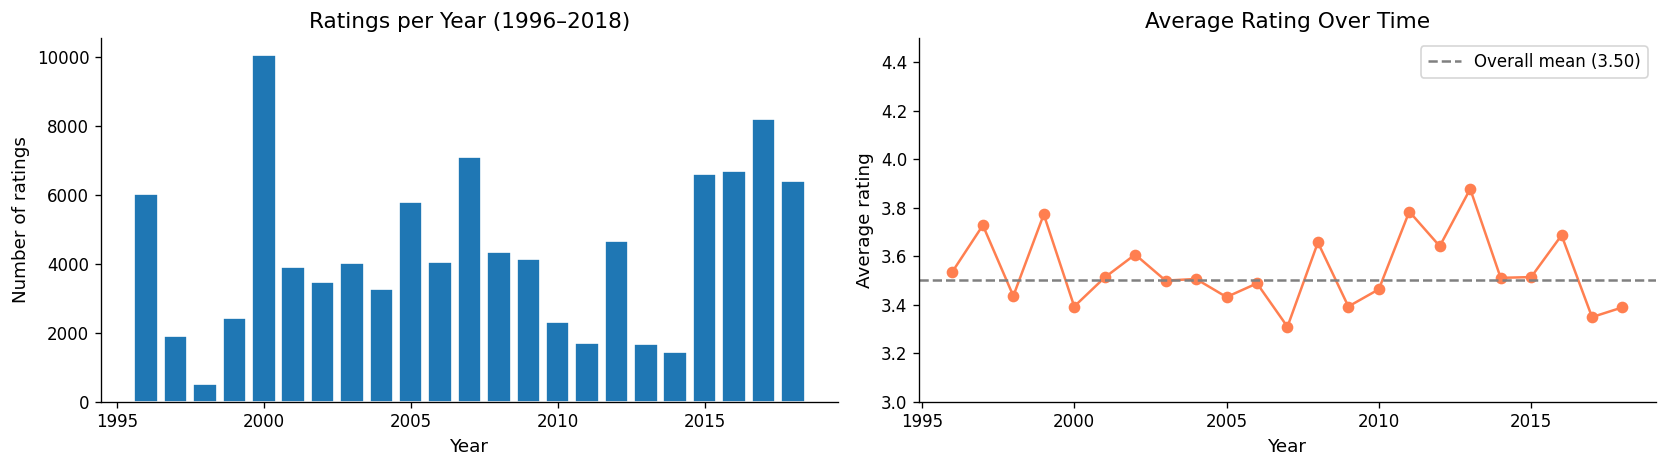

Dataset spans: 1996-03-29 → 2018-09-24
Peak year: 2000 (10,061 ratings)


In [7]:
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Ratings per year
year_counts = ratings.groupby('year').size()
axes[0].bar(year_counts.index, year_counts.values, color='#1f77b4', edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of ratings')
axes[0].set_title('Ratings per Year (1996–2018)')

# Average rating per year
avg_by_year = ratings.groupby('year')['rating'].mean()
axes[1].plot(avg_by_year.index, avg_by_year.values, marker='o', color='coral')
axes[1].axhline(avg_r, color='grey', linestyle='--', label=f'Overall mean ({avg_r:.2f})')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average rating')
axes[1].set_ylim(3.0, 4.5)
axes[1].set_title('Average Rating Over Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_temporal.png', bbox_inches='tight')
plt.show()

print(f"Dataset spans: {ratings['date'].min().date()} → {ratings['date'].max().date()}")
print(f"Peak year: {year_counts.idxmax()} ({year_counts.max():,} ratings)")

---
## 7. Matrix Sparsity Visualisation

The user-item matrix is the input to collaborative filtering. Visualising a sample of it makes the sparsity problem tangible.

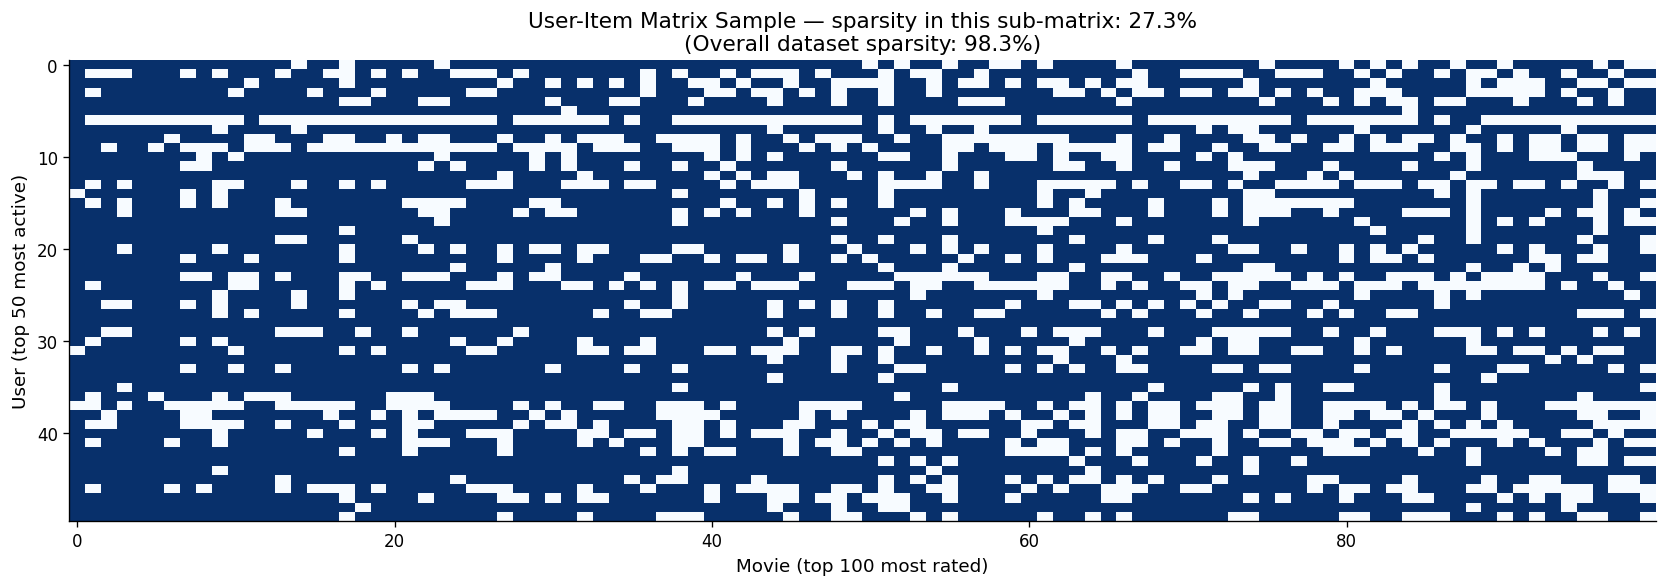

Even among the 50 most active users and 100 most popular movies,
sparsity is 27.3%.
For the full matrix it is 98.3% — only 1.70% of entries are observed.


In [8]:
# Sample 50 most-active users and 100 most-rated movies
top50_users  = ratings.groupby('userId').size().nlargest(50).index
top100_items = ratings.groupby('movieId').size().nlargest(100).index

sample = ratings[ratings['userId'].isin(top50_users) & ratings['movieId'].isin(top100_items)]
pivot  = sample.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)

# Ensure all 100 items are present even if user didn't rate them
pivot = pivot.reindex(columns=top100_items, fill_value=0)

full_sparsity = 1 - (pivot > 0).values.sum() / pivot.size

fig, ax = plt.subplots(figsize=(14, 5))
mask = pivot.values == 0
ax.imshow(pivot.values > 0, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xlabel('Movie (top 100 most rated)')
ax.set_ylabel('User (top 50 most active)')
ax.set_title(
    f'User-Item Matrix Sample — sparsity in this sub-matrix: {full_sparsity:.1%}\n'
    f'(Overall dataset sparsity: {sparsity:.1%})'
)
plt.tight_layout()
plt.savefig('fig_sparsity.png', bbox_inches='tight')
plt.show()

print(f'Even among the 50 most active users and 100 most popular movies,')
print(f'sparsity is {full_sparsity:.1%}.')
print(f'For the full matrix it is {sparsity:.1%} — only {1-sparsity:.2%} of entries are observed.')

---
## 8. Tags Analysis

User-generated tags are used in the Content-Based recommender alongside genres. This section checks coverage.

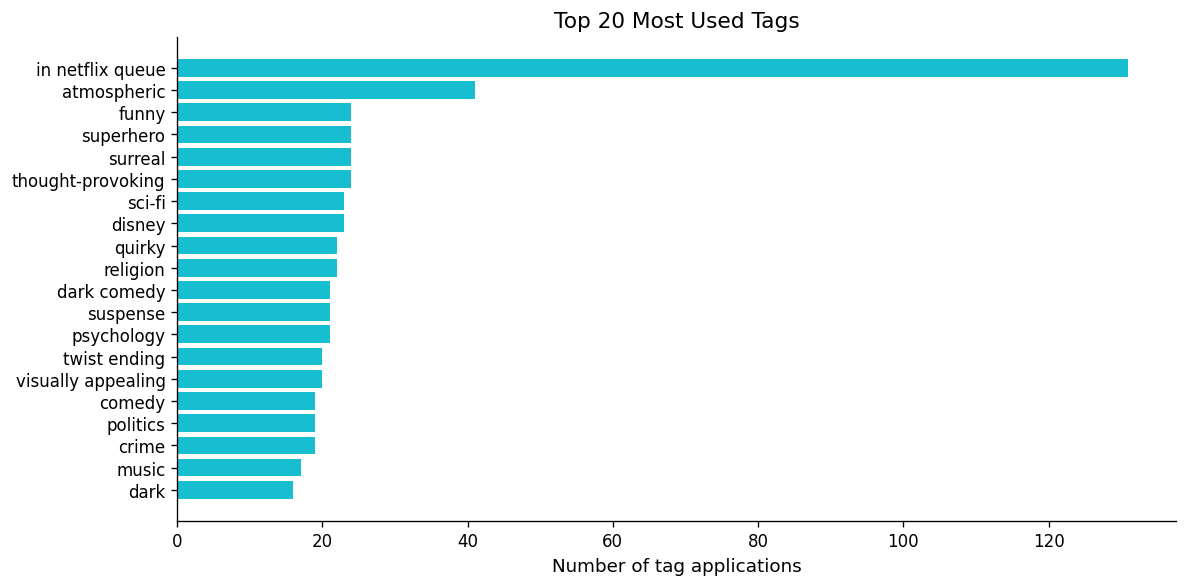

Unique tags:          1,589
Movies with tags:     1,572 (16.2% of rated movies)
Avg tags per movie:   2.3

Note: 84% of movies have no tags — those rely solely on genre vectors.


In [9]:
tagged_movies = tags['movieId'].nunique()
tag_coverage  = tagged_movies / n_items

top_tags = tags['tag'].str.lower().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color='#17becf')
ax.set_xlabel('Number of tag applications')
ax.set_title('Top 20 Most Used Tags')
plt.tight_layout()
plt.savefig('fig_tags.png', bbox_inches='tight')
plt.show()

print(f'Unique tags:          {tags["tag"].nunique():,}')
print(f'Movies with tags:     {tagged_movies:,} ({tag_coverage:.1%} of rated movies)')
print(f'Avg tags per movie:   {tags.groupby("movieId").size().mean():.1f}')
print(f'\nNote: {(1-tag_coverage):.0%} of movies have no tags — those rely solely on genre vectors.')

---
## 9. Key Findings & Implications for Recommender Design

| Finding | Implication |
|---------|-------------|
| **98.3% sparsity** | Collaborative filtering based on raw ratings is noisy; Matrix Factorization helps by compressing the matrix into latent factors |
| **Long-tail popularity** | Popularity baselines are strongly biased towards blockbusters; CF also inherits this bias; Content-Based is less affected |
| **Positive rating bias** | Users rate movies they chose to watch → ratings skew positive; precision-recall metrics underestimate true recommendation quality |
| **Cold-start users** (~7% with <20 ratings) | CF and MF will struggle; Content-Based or popularity fallbacks are needed |
| **Tag coverage ~45%** | Combining genres + tags in TF-IDF enriches item vectors but leaves ~55% of movies relying on genre alone |
| **Genre imbalance** | Drama and Comedy dominate → genre-only content-based has low diversity; tags help differentiate within genres |

These findings motivate:
- Using **Matrix Factorization** to handle sparsity
- Combining **genres + tags** in the Content-Based model
- Evaluating **beyond accuracy** (Novelty, Coverage) to capture the accuracy–diversity trade-off
- Reporting **popularity bias** (AvgPopularity metric) to make the blockbuster effect explicit